# Credit Scoring Model

## CodeAlpha Machine Learning Internship

### Project Overview

This project develops a machine learning model to predict the likelihood of credit card default based on customer financial and repayment history.

The project follows a complete machine learning workflow:

* Data loading and exploration
* Data cleaning and preprocessing
* Exploratory data analysis
* Feature analysis
* Train-test splitting
* Model training
* Model comparison
* Class imbalance handling
* Model evaluation
* Feature importance analysis
* Model saving and prediction

### Models Used

Three classification algorithms were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Because the target variable was imbalanced, balanced class weights were also evaluated. The Balanced Random Forest model was selected as the final model based on its overall F1-score and ROC-AUC performance.

### Dataset

The project uses the UCI Default of Credit Card Clients dataset.

### Objective

The objective is to build a model that can identify customers who are at risk of credit default while evaluating the model using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.


## 1. Import Libraries and Load Dataset

In [2]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the Credit Card Default dataset
from ucimlrepo import fetch_ucirepo

credit_data = fetch_ucirepo(id=350)

# Separate features and target
X = credit_data.data.features
y = credit_data.data.targets

# Display basic information
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display the first 5 rows
X.head()

Features shape: (30000, 23)
Target shape: (30000, 1)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


## 2. Data Understanding and Exploration

In [3]:
# Basic information about the dataset
print("Dataset Information:")
print(X.info())

print("\nColumn Names:")
print(X.columns.tolist())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nFirst 5 Target Values:")
print(y.head())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes

In [4]:
# Statistical summary of numerical features
X.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [5]:
# Check the distribution of the target variable

print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target distribution:
Y
0    23364
1     6636
Name: count, dtype: int64

Target percentage:
Y
0    77.88
1    22.12
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

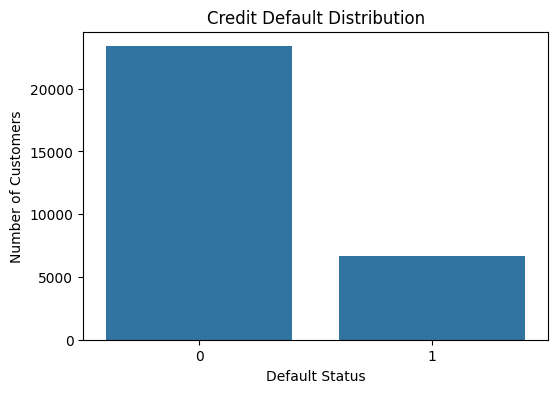

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize target distribution
plt.figure(figsize=(6, 4))

sns.countplot(x=y.iloc[:, 0])

plt.title("Credit Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
# Rename the dataset columns with meaningful names

column_names = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

X.columns = column_names

# Display the renamed columns
print(X.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## 4. Data Cleaning

In [9]:
# Check for duplicate rows

duplicates = X.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 56


In [10]:
# Check whether duplicate feature rows have consistent target labels

data_check = X.copy()
data_check["DEFAULT"] = y.iloc[:, 0].values

# Find rows duplicated across features
duplicate_rows = data_check[data_check.duplicated(subset=X.columns, keep=False)]

print("Total duplicate feature rows:", len(duplicate_rows))

# Check whether duplicates have different target labels
conflicting_duplicates = (
    duplicate_rows.groupby(list(X.columns))["DEFAULT"]
    .nunique()
)

print(
    "Duplicate feature groups with conflicting target labels:",
    (conflicting_duplicates > 1).sum()
)

Total duplicate feature rows: 108
Duplicate feature groups with conflicting target labels: 21


In [11]:
# Remove rows where the complete feature set is duplicated
# This avoids contradictory labels and potential data leakage.

duplicate_mask = X.duplicated(subset=X.columns, keep=False)

X_clean = X[~duplicate_mask].copy()
y_clean = y.loc[X_clean.index].copy()

print("Original dataset size:", X.shape)
print("Cleaned dataset size:", X_clean.shape)
print("Rows removed:", X.shape[0] - X_clean.shape[0])

Original dataset size: (30000, 23)
Cleaned dataset size: (29892, 23)
Rows removed: 108


In [12]:
# Check unique values in categorical features

print("SEX values:")
print(X_clean["SEX"].value_counts().sort_index())

print("\nEDUCATION values:")
print(X_clean["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE values:")
print(X_clean["MARRIAGE"].value_counts().sort_index())

SEX values:
SEX
1    11845
2    18047
Name: count, dtype: int64

EDUCATION values:
EDUCATION
0       14
1    10521
2    13994
3     4909
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE values:
MARRIAGE
0       54
1    13607
2    15908
3      323
Name: count, dtype: int64


In [13]:
# Add target to our cleaned dataset for analysis

eda_data = X_clean.copy()
eda_data["DEFAULT"] = y_clean.iloc[:, 0].values

# Default rate by education
education_default = (
    eda_data.groupby("EDUCATION")["DEFAULT"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default rate by education (%):")
print(education_default)

# Default rate by marriage
marriage_default = (
    eda_data.groupby("MARRIAGE")["DEFAULT"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nDefault rate by marriage (%):")
print(marriage_default)

# Default rate by sex
sex_default = (
    eda_data.groupby("SEX")["DEFAULT"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nDefault rate by sex (%):")
print(sex_default)

Default rate by education (%):
EDUCATION
0     0.00
1    19.17
2    23.72
3    25.16
4     5.69
5     6.43
6    15.69
Name: DEFAULT, dtype: float64

Default rate by marriage (%):
MARRIAGE
0     9.26
1    23.41
2    20.93
3    26.01
Name: DEFAULT, dtype: float64

Default rate by sex (%):
SEX
1    24.13
2    20.76
Name: DEFAULT, dtype: float64


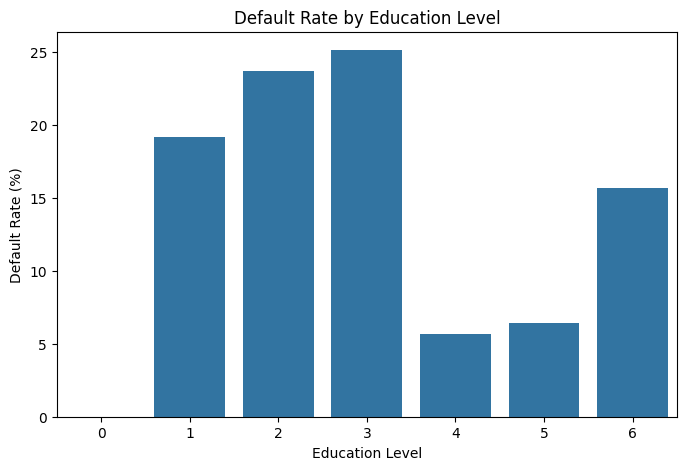

In [14]:
# Visualize default rate by education level

plt.figure(figsize=(8, 5))

sns.barplot(
    x=education_default.index,
    y=education_default.values
)

plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")

plt.show()

In [15]:
# Default rate based on most recent repayment status

pay_default = (
    eda_data.groupby("PAY_0")["DEFAULT"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default rate by most recent repayment status:")
print(pay_default)

Default rate by most recent repayment status:
PAY_0
-2    13.16
-1    16.80
 0    12.81
 1    33.94
 2    69.14
 3    75.78
 4    68.42
 5    50.00
 6    54.55
 7    77.78
 8    57.89
Name: DEFAULT, dtype: float64


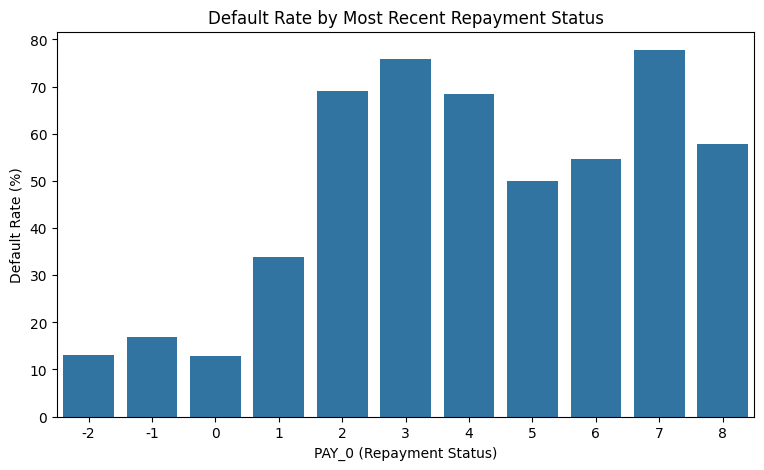

In [16]:
# Visualize default rate by repayment status

plt.figure(figsize=(9, 5))

sns.barplot(
    x=pay_default.index,
    y=pay_default.values
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0 (Repayment Status)")
plt.ylabel("Default Rate (%)")

plt.show()

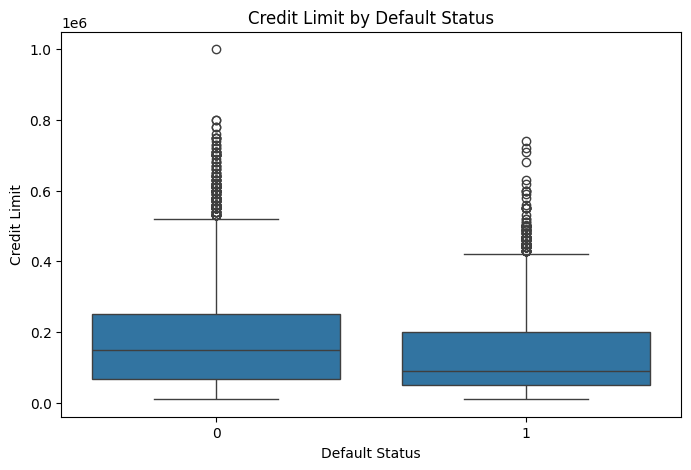

In [17]:
# Compare credit limit between defaulters and non-defaulters

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="DEFAULT",
    y="LIMIT_BAL",
    data=eda_data
)

plt.title("Credit Limit by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Credit Limit")

plt.show()

## 5. Feature Correlation Analysis

In [18]:
# Calculate correlations with the target

correlations = eda_data.corr(numeric_only=True)["DEFAULT"].drop("DEFAULT")

# Sort by absolute correlation
correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

print("Features most correlated with default:")
print(correlations)

Features most correlated with default:
PAY_0        0.325332
PAY_2        0.266035
PAY_3        0.237429
PAY_4        0.218645
PAY_5        0.206107
PAY_6        0.188640
LIMIT_BAL   -0.154938
PAY_AMT1    -0.072878
PAY_AMT2    -0.058544
PAY_AMT4    -0.056756
PAY_AMT3    -0.056185
PAY_AMT5    -0.055044
PAY_AMT6    -0.053113
SEX         -0.039748
EDUCATION    0.028463
MARRIAGE    -0.023529
BILL_AMT1   -0.019250
BILL_AMT2   -0.013785
BILL_AMT3   -0.013675
AGE          0.013351
BILL_AMT4   -0.009748
BILL_AMT5   -0.006347
BILL_AMT6   -0.004962
Name: DEFAULT, dtype: float64


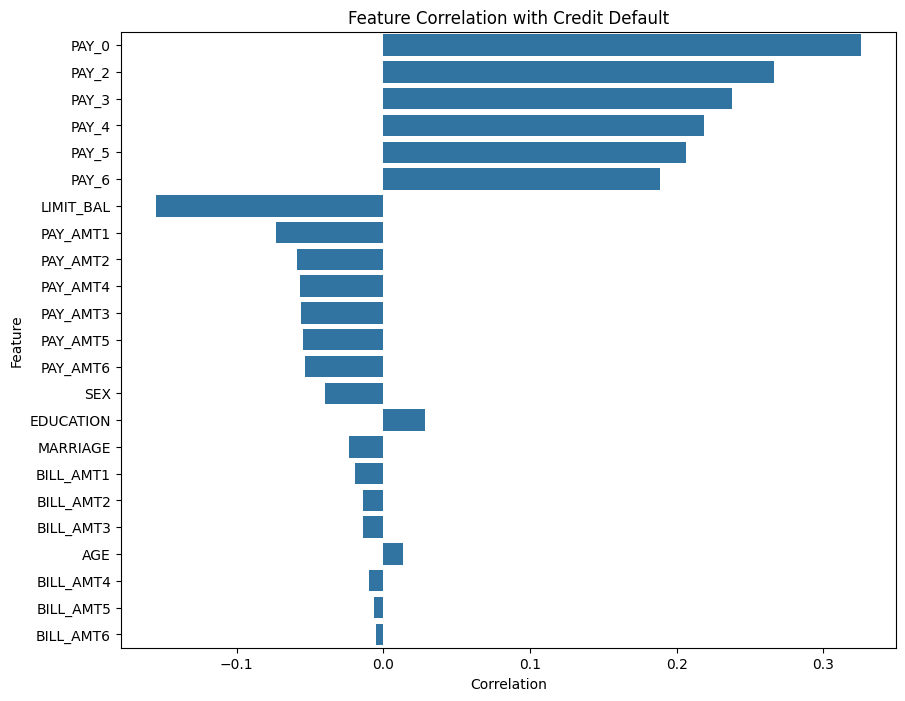

In [19]:
# Visualize correlations with default

plt.figure(figsize=(10, 8))

sns.barplot(
    x=correlations.values,
    y=correlations.index
)

plt.title("Feature Correlation with Credit Default")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [20]:
# Prepare features and target for machine learning

X_model = X_clean.copy()
y_model = y_clean.iloc[:, 0].copy()

print("Features shape:", X_model.shape)
print("Target shape:", y_model.shape)

Features shape: (29892, 23)
Target shape: (29892,)


## 6. Data Preprocessing

In [21]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (23913, 23)
Testing set: (5979, 23)

Training target distribution:
Y
0    77.907414
1    22.092586
Name: proportion, dtype: float64

Testing target distribution:
Y
0    77.906004
1    22.093996
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit only on training data, then transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (23913, 23)
Scaled testing data shape: (5979, 23)


## 7. Model Training

In [23]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [24]:
# Make predictions on the test set

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions:")
print(y_pred_lr[:10])

print("\nFirst 10 prediction probabilities:")
print(y_prob_lr[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 prediction probabilities:
[0.19223126 0.21834716 0.08824686 0.09674681 0.12567955 0.1931572
 0.42372094 0.12476947 0.05427588 0.29185481]


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.8125
Precision: 0.7165
Recall   : 0.2506
F1-Score : 0.3713
ROC-AUC  : 0.7282


In [26]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [27]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("-" * 35)
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

Decision Tree Results
-----------------------------------
Accuracy : 0.8162
Precision: 0.6500
Recall   : 0.3641
F1-Score : 0.4668
ROC-AUC  : 0.7522


In [28]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [29]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.8162
Precision: 0.6550
Recall   : 0.3550
F1-Score : 0.4605
ROC-AUC  : 0.7773


## 8. Model Evaluation and Comparison

In [30]:
# Compare all three models

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_dt, accuracy_rf],
    "Precision": [precision_lr, precision_dt, precision_rf],
    "Recall": [recall_lr, recall_dt, recall_rf],
    "F1-Score": [f1_lr, f1_dt, f1_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_dt, roc_auc_rf]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8125,0.7165,0.2506,0.3713,0.7282
1,Decision Tree,0.8162,0.6500,0.3641,0.4668,0.7522
2,Random Forest,0.8162,0.6550,0.3550,0.4605,0.7773


## 9. Handling Class Imbalance

In [31]:
# Train models with balanced class weights

# Balanced Logistic Regression
logistic_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_balanced.fit(X_train_scaled, y_train)

y_pred_lr_bal = logistic_balanced.predict(X_test_scaled)
y_prob_lr_bal = logistic_balanced.predict_proba(X_test_scaled)[:, 1]


# Balanced Decision Tree
decision_tree_balanced = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

decision_tree_balanced.fit(X_train, y_train)

y_pred_dt_bal = decision_tree_balanced.predict(X_test)
y_prob_dt_bal = decision_tree_balanced.predict_proba(X_test)[:, 1]


# Balanced Random Forest
random_forest_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_balanced.fit(X_train, y_train)

y_pred_rf_bal = random_forest_balanced.predict(X_test)
y_prob_rf_bal = random_forest_balanced.predict_proba(X_test)[:, 1]

print("Balanced models trained successfully!")

Balanced models trained successfully!


In [32]:
# Evaluate balanced models

balanced_comparison = pd.DataFrame({
    "Model": [
        "Balanced Logistic Regression",
        "Balanced Decision Tree",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr_bal),
        accuracy_score(y_test, y_pred_dt_bal),
        accuracy_score(y_test, y_pred_rf_bal)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr_bal),
        precision_score(y_test, y_pred_dt_bal),
        precision_score(y_test, y_pred_rf_bal)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr_bal),
        recall_score(y_test, y_pred_dt_bal),
        recall_score(y_test, y_pred_rf_bal)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr_bal),
        f1_score(y_test, y_pred_dt_bal),
        f1_score(y_test, y_pred_rf_bal)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr_bal),
        roc_auc_score(y_test, y_prob_dt_bal),
        roc_auc_score(y_test, y_prob_rf_bal)
    ]
})

balanced_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Balanced Logistic Regression,0.6812,0.3734,0.6533,0.4752,0.7289
1,Balanced Decision Tree,0.7883,0.5200,0.5405,0.5301,0.7596
2,Balanced Random Forest,0.7745,0.4916,0.5958,0.5387,0.7761


## 10. Final Model Analysis

Confusion Matrix:
[[3844  814]
 [ 534  787]]


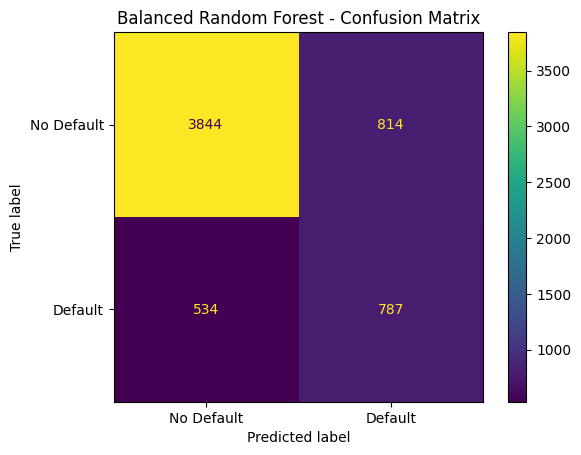

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix for the final model
cm = confusion_matrix(y_test, y_pred_rf_bal)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot()

plt.title("Balanced Random Forest - Confusion Matrix")
plt.show()

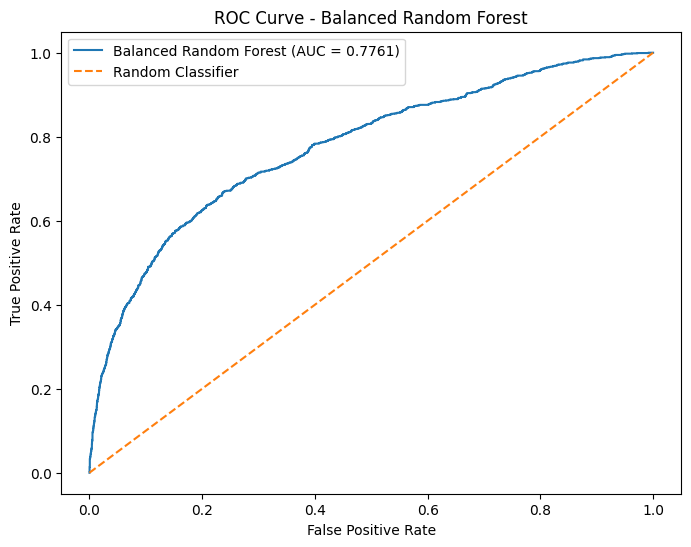

In [34]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf_bal)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Balanced Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Random Forest")
plt.legend()

plt.show()

In [35]:
# Get feature importance from the final Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_balanced.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
      Feature  Importance
5       PAY_0    0.250866
6       PAY_2    0.093461
7       PAY_3    0.057476
8       PAY_4    0.054016
0   LIMIT_BAL    0.048180
10      PAY_6    0.045477
11  BILL_AMT1    0.041633
17   PAY_AMT1    0.041329
18   PAY_AMT2    0.039384
9       PAY_5    0.036419


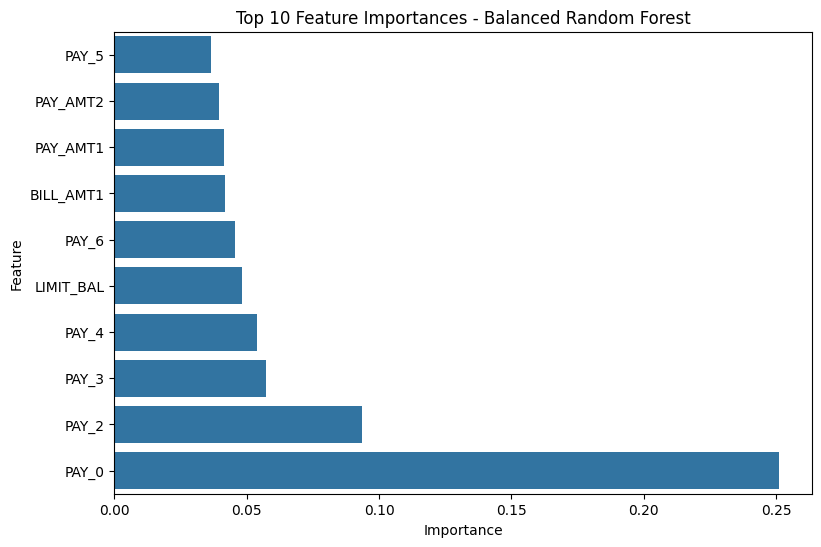

In [36]:
# Visualize the top 10 features

top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Feature Importances - Balanced Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 11. Model Saving and Prediction

In [37]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the final Random Forest model
joblib.dump(
    random_forest_balanced,
    "../models/credit_scoring_random_forest.pkl"
)

# Save the scaler as well
joblib.dump(
    scaler,
    "../models/credit_scoring_scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [38]:
# Load the saved Random Forest model
loaded_model = joblib.load("../models/credit_scoring_random_forest.pkl")

# Select one customer from the test set
sample_customer = X_test.iloc[[0]]

# Make prediction
prediction = loaded_model.predict(sample_customer)[0]
probability = loaded_model.predict_proba(sample_customer)[0]

print("Predicted class:", prediction)
print("Probability of No Default:", f"{probability[0] * 100:.2f}%")
print("Probability of Default:", f"{probability[1] * 100:.2f}%")

if prediction == 1:
    print("\nPrediction: Customer is likely to default.")
else:
    print("\nPrediction: Customer is unlikely to default.")

Predicted class: 0
Probability of No Default: 80.14%
Probability of Default: 19.86%

Prediction: Customer is unlikely to default.
